# EFF 2017 – Data Explorer
Quick interactive viewer for `eff.dta` and `secondlang_prob.dta`.

In [26]:
import pandas as pd
import numpy as np

DATA_DIR = "toshare"

eff = pd.read_stata(f"{DATA_DIR}/eff.dta")
sl  = pd.read_stata(f"{DATA_DIR}/secondlang_prob.dta")

print(f"eff shape      : {eff.shape}")
print(f"secondlang shape: {sl.shape}")

eff shape      : (32065, 56)
secondlang shape: (12, 2)


## 1 · `eff.dta` – first rows

In [27]:
eff.head(10)

,h_2017,imp,facine3,hhsize,age_resp,gender_resp,educ_resp,genera,own,own_ot,...,une_8,une_9,ret_2,ret_3,ret_4,ret_5,ret_6,ret_7,ret_8,ret_9
0,1.0,1.0,3588.511112,2.0,74.0,1.0,2.0,Silent,1.0,0.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.0,1.0,153.944894,2.0,71.0,0.0,8.0,Boomers,1.0,1.0,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100.0,1.0,9116.346418,3.0,69.0,0.0,2.0,Boomers,1.0,1.0,...,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1000.0,1.0,7098.222050,2.0,75.0,1.0,2.0,Silent,0.0,0.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001.0,1.0,3526.242879,4.0,51.0,0.0,8.0,Exers,1.0,1.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1002.0,1.0,3636.284832,1.0,59.0,1.0,2.0,Boomers,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1003.0,1.0,58.215763,1.0,85.0,0.0,1002.0,Silent,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1004.0,1.0,2612.982879,4.0,47.0,0.0,3.0,Exers,1.0,1.0,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
8,1005.0,1.0,2260.102971,2.0,62.0,0.0,2.0,Boomers,1.0,1.0,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1006.0,1.0,6985.167620,1.0,74.0,1.0,2.0,Silent,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2 · Column types & missing values

In [28]:
info = pd.DataFrame({
    "dtype"  : eff.dtypes,
    "n_null" : eff.isna().sum(),
    "pct_null": (eff.isna().mean() * 100).round(2),
    "n_unique": eff.nunique()
})
info

,dtype,n_null,pct_null,n_unique
h_2017,float64,0,0.00,6413
imp,float64,0,0.00,5
facine3,float64,0,0.00,5279
hhsize,float64,0,0.00,10
age_resp,float64,0,0.00,68
gender_resp,float64,0,0.00,2
educ_resp,float64,0,0.00,14
genera,str,0,0.00,4
own,float64,0,0.00,2
own_ot,float64,0,0.00,2


## 3 · Descriptive statistics (numeric columns)

In [29]:
eff.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

,count,mean,std,min,10%,25%,50%,75%,90%,max
h_2017,32065.0,3.207000e+03,1.851302e+03,1.000000e+00,642.000000,1604.000000,3207.000000,4810.000000,5.772000e+03,6.413000e+03
imp,32065.0,3.000000e+00,1.414236e+00,1.000000e+00,1.000000,2.000000,3.000000,4.000000,5.000000e+00,5.000000e+00
facine3,32065.0,2.890442e+03,3.489604e+03,2.193108e+00,38.227813,186.360330,2260.102971,3867.047327,6.479798e+03,5.333691e+04
hhsize,32065.0,2.547482e+00,1.258132e+00,1.000000e+00,1.000000,2.000000,2.000000,3.000000,4.000000e+00,1.000000e+01
age_resp,32065.0,6.032496e+01,1.484028e+01,1.900000e+01,40.000000,49.000000,61.000000,72.000000,8.000000e+01,8.600000e+01
gender_resp,32065.0,3.842196e-01,4.864178e-01,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00
educ_resp,32065.0,2.847003e+02,4.477168e+02,1.000000e+00,2.000000,3.000000,6.000000,1001.000000,1.002000e+03,1.002000e+03
own,32065.0,8.214252e-01,3.830018e-01,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
own_ot,32065.0,6.054265e-01,4.887665e-01,0.000000e+00,0.000000,0.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
neg,32065.0,1.542180e-01,3.611632e-01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00


## 4 · Key variable distributions

In [30]:
# Implicate counts
print("=== imp ===")
print(eff["imp"].value_counts().sort_index())

print("\n=== own (main residence) ===")
print(eff["own"].value_counts())

print("\n=== own_ot (secondary home) ===")
print(eff["own_ot"].value_counts())

print("\n=== neg (business) ===")
print(eff["neg"].value_counts())

print("\n=== gender_resp (1=woman, 0=man) ===")
print(eff["gender_resp"].value_counts())

print("\n=== educ_resp ===")
print(eff["educ_resp"].value_counts().sort_index())

=== imp ===
imp
1.0    6413
2.0    6413
3.0    6413
4.0    6413
5.0    6413
Name: count, dtype: int64

=== own (main residence) ===
own
1.0    26339
0.0     5726
Name: count, dtype: int64

=== own_ot (secondary home) ===
own_ot
1.0    19413
0.0    12652
Name: count, dtype: int64

=== neg (business) ===
neg
0.0    27120
1.0     4945
Name: count, dtype: int64

=== gender_resp (1=woman, 0=man) ===
gender_resp
0.0    19745
1.0    12320
Name: count, dtype: int64

=== educ_resp ===
educ_resp
1.0        510
2.0       6935
3.0        635
4.0       4030
5.0        645
6.0       4575
7.0        455
8.0       2755
9.0        395
11.0      1190
12.0       915
97.0        30
1001.0    2915
1002.0    6080
Name: count, dtype: int64


## 5 · Wealth & debt overview (imp == 1)

In [31]:
eff1 = eff[eff["imp"] == 1].copy()

wealth_cols = ["totnet", "finet", "realest", "deud", "deudre",
               "val_main", "val_othe", "hh_inc"]

eff1[wealth_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T.round(0)

,count,mean,std,min,25%,50%,75%,90%,99%,max
totnet,6413.0,1676204.0,12288604.0,-169000.0,78303.0,239600.0,857530.0,2722195.0,21189986.0,631252980.0
finet,6413.0,588375.0,7062276.0,-3665953.0,2232.0,25000.0,165599.0,769475.0,7267100.0,398220000.0
realest,6413.0,1133629.0,9385437.0,0.0,95000.0,228144.0,622729.0,1792748.0,13115976.0,626881231.0
deud,6413.0,44871.0,201373.0,0.0,0.0,0.0,30500.0,113500.0,520097.0,6785849.0
deudre,6413.0,38409.0,171480.0,0.0,0.0,0.0,23000.0,104000.0,479400.0,5600000.0
val_main,6413.0,246490.0,383132.0,0.0,60000.0,150000.0,300000.0,593353.0,1800000.0,7000000.0
val_othe,6413.0,451658.0,2584617.0,0.0,0.0,36591.0,262121.0,910732.0,5895200.0,123020242.0
hh_inc,6413.0,32130.0,74644.0,0.0,13176.0,24192.0,38964.0,60000.0,139200.0,4834800.0


## 6 · Age distribution (imp == 1)

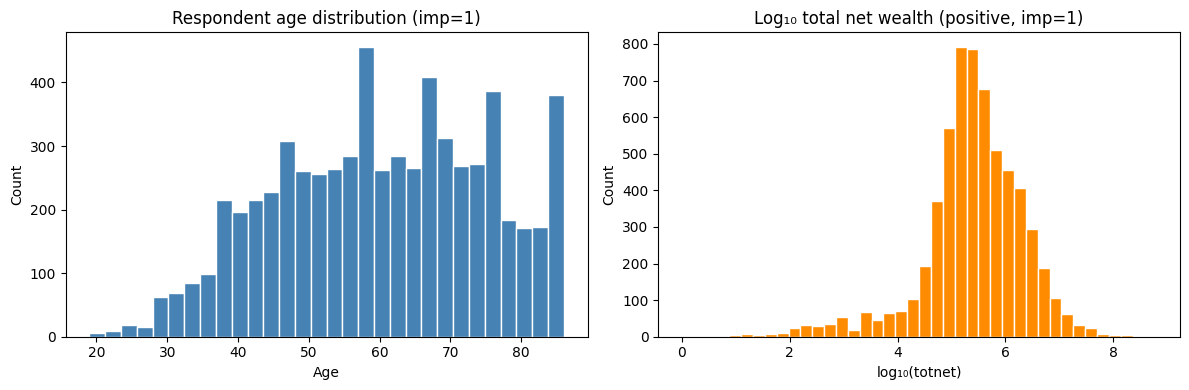

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age histogram
axes[0].hist(eff1["age_resp"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Respondent age distribution (imp=1)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Net wealth histogram (log scale, positive only)
pos_wealth = eff1["totnet"][eff1["totnet"] > 0]
axes[1].hist(np.log10(pos_wealth), bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("Log₁₀ total net wealth (positive, imp=1)")
axes[1].set_xlabel("log₁₀(totnet)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 7 · `secondlang_prob.dta` – full table

In [33]:
sl.sort_values("educ_resp").reset_index(drop=True)

,educ_resp,p_knows_second_lang
0,1.0,0.148047
1,2.0,0.182426
2,3.0,0.222700
3,4.0,0.268941
4,6.0,0.377541
5,8.0,0.500000
6,9.0,0.562177
7,11.0,0.731059
8,12.0,0.777300
9,97.0,0.461075


## 8 · Free-form filter / slice
Edit the cell below to explore any subset you need.

In [34]:
# Example: households aged 30-40 with main residence, imp=1
(
    eff1
    .query("age_resp >= 30 and age_resp <= 40 and own == 1")
    [["h_2017", "age_resp", "gender_resp", "educ_resp",
      "hhsize", "totnet", "hh_inc", "own", "own_ot", "neg"]]
    .head(20)
)

,h_2017,age_resp,gender_resp,educ_resp,hhsize,totnet,hh_inc,own,own_ot,neg
38,1032.0,36.0,0.0,6.0,2.0,6.110000e+04,17268.000000,1.0,0.0,0.0
47,1040.0,35.0,1.0,1002.0,4.0,9.175500e+04,58356.000000,1.0,0.0,0.0
63,1055.0,40.0,1.0,1002.0,3.0,3.420000e+05,7200.000000,1.0,1.0,1.0
66,1058.0,32.0,0.0,1002.0,4.0,3.699480e+05,29232.000000,1.0,1.0,0.0
71,1062.0,32.0,1.0,8.0,2.0,1.734410e+05,0.000000,1.0,1.0,1.0
74,1065.0,40.0,1.0,1002.0,4.0,1.301977e+06,45600.000000,1.0,1.0,1.0
113,110.0,33.0,0.0,11.0,4.0,1.172300e+04,68400.000000,1.0,0.0,0.0
135,112.0,38.0,1.0,8.0,4.0,1.688530e+05,25200.000000,1.0,0.0,1.0
148,1131.0,36.0,1.0,1001.0,3.0,3.708200e+05,0.000000,1.0,1.0,1.0
163,1145.0,36.0,0.0,3.0,4.0,4.623900e+04,21792.000000,1.0,0.0,0.0


---
## 9 · `secondlang_prob.dta` — full explorer

In [35]:

# Education level labels (from codebook)
educ_labels = {
    1:    "Illiterate",
    2:    "Primary",
    3:    "Vocational (< ESO)",
    4:    "Lower secondary (ESO)",
    5:    "Vocational (ESO) [not in sl]",
    6:    "Upper secondary (Bachillerato)",
    7:    "Vocational (Bachillerato) [not in sl]",
    8:    "Specialised vocational / Higher",
    9:    "Post-secondary (2+ yr)",
    11:   "Master's degree",
    12:   "PhD",
    97:   "Other",
    1001: "Short-cycle university (Diplomado)",
    1002: "Long-cycle university (Licenciado)",
}

sl_view = (
    sl
    .assign(
        educ_resp   = sl["educ_resp"].astype(int),
        educ_label  = sl["educ_resp"].astype(int).map(educ_labels),
        in_eff_data = sl["educ_resp"].astype(int).map(
            lambda x: "✓ matched" if x not in (5, 7) else "✗ missing in sl"
        ),
    )
    .sort_values("educ_resp")
    .reset_index(drop=True)
    [["educ_resp", "educ_label", "p_knows_second_lang", "in_eff_data"]]
)

sl_view


,educ_resp,educ_label,p_knows_second_lang,in_eff_data
0,1,Illiterate,0.148047,✓ matched
1,2,Primary,0.182426,✓ matched
2,3,Vocational (< ESO),0.222700,✓ matched
3,4,Lower secondary (ESO),0.268941,✓ matched
4,6,Upper secondary (Bachillerato),0.377541,✓ matched
5,8,Specialised vocational / Higher,0.500000,✓ matched
6,9,Post-secondary (2+ yr),0.562177,✓ matched
7,11,Master's degree,0.731059,✓ matched
8,12,PhD,0.777300,✓ matched
9,97,Other,0.461075,✓ matched


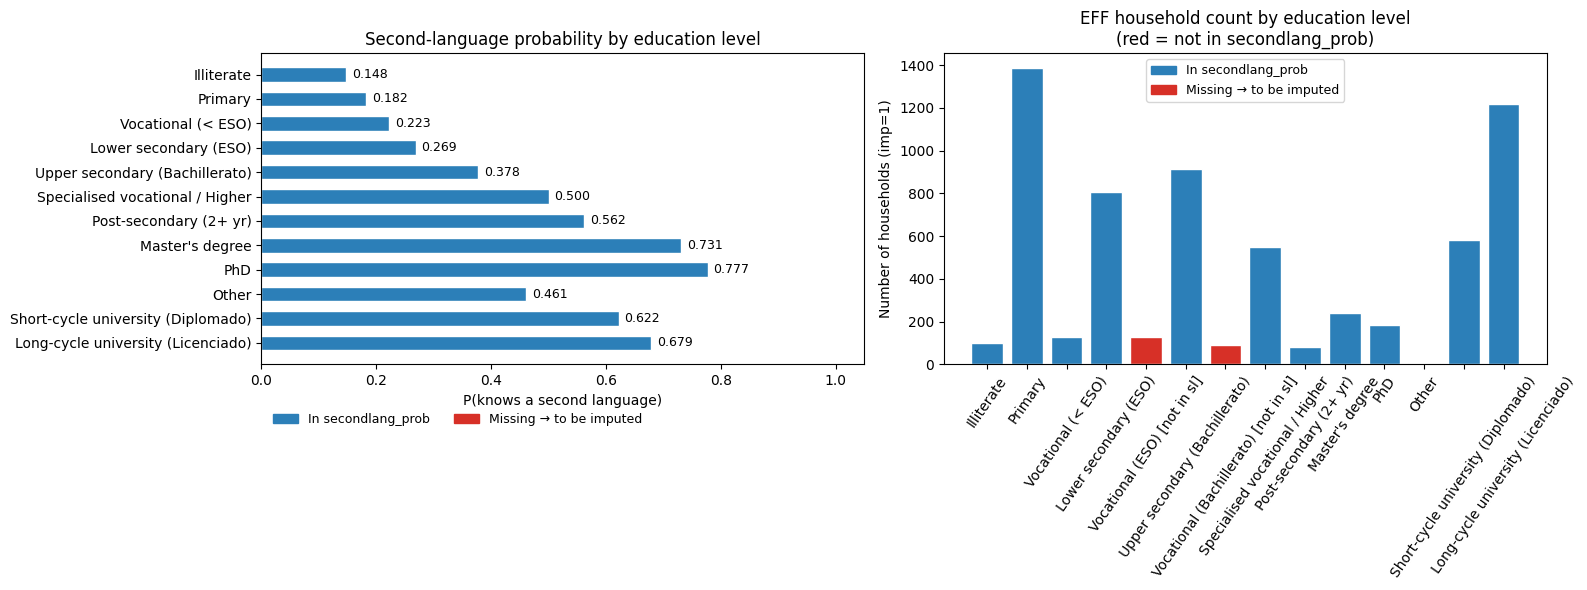


Households NOT matched in sl (educ 5 or 7): 220 (3.4%)


In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: horizontal bar chart ---
colours = ["#2c7fb8" if x not in (5, 7) else "#d73027"
           for x in sl_view["educ_resp"]]

bars = axes[0].barh(
    sl_view["educ_label"],
    sl_view["p_knows_second_lang"],
    color=colours,
    edgecolor="white",
    height=0.6,
)
axes[0].set_xlabel("P(knows a second language)")
axes[0].set_title("Second-language probability by education level")
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, sl_view["p_knows_second_lang"]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=9)
axes[0].invert_yaxis()

blue_patch = mpatches.Patch(color="#2c7fb8", label="In secondlang_prob")
red_patch  = mpatches.Patch(color="#d73027", label="Missing → to be imputed")
axes[0].legend(
    handles=[blue_patch, red_patch],
    loc="upper left",
    bbox_to_anchor=(0, -0.12),
    ncol=2,
    frameon=False,
    fontsize=9,
)

# --- Right: merge coverage in eff (imp=1) ---
eff1_educ = eff[eff["imp"] == 1]["educ_resp"].astype(int)
sl_educ_set = set(sl["educ_resp"].astype(int))

coverage = (
    eff1_educ
    .value_counts()
    .reset_index()
    .rename(columns={"educ_resp": "educ_resp", "count": "n"})
    .assign(
        matched = lambda d: d["educ_resp"].isin(sl_educ_set),
        label   = lambda d: d["educ_resp"].map(educ_labels).fillna("Unknown"),
    )
    .sort_values("educ_resp")
)

bar_colours = ["#2c7fb8" if m else "#d73027" for m in coverage["matched"]]
axes[1].bar(coverage["label"], coverage["n"], color=bar_colours, edgecolor="white")
axes[1].set_ylabel("Number of households (imp=1)")
axes[1].set_title("EFF household count by education level\n(red = not in secondlang_prob)")
axes[1].tick_params(axis="x", rotation=55)
axes[1].legend(
    handles=[blue_patch, red_patch],
    loc="upper center",
    fontsize=9,
)

plt.tight_layout()
plt.show()

print(f"\nHouseholds NOT matched in sl (educ 5 or 7): "
      f"{(~eff1_educ.isin(sl_educ_set)).sum()} "
      f"({(~eff1_educ.isin(sl_educ_set)).mean()*100:.1f}%)")
